# Prédiction des scores de matchs de football

---
#Objectif du projet
 **Objectif général**

 Prédire le résultat d’un match de football à partir de statistiques historiques des équipes participantes (estimer la probabilité qu’une équipe remporte un match).

 **Objectifs spécifiques**

 Analyser et comprendre les données de matchs

Développement un modèle de Régression

Évaluer les performances du modèle

---
#Contenu du dataset

X dans le nom de la caractéristique est soit home ou away, indiquant si la caractéristique
est pour l’équipe à domicile ou l’équipe extérieure.

**Informations temporelles**

date : date du match

**Performances offensives**

X_goals_mean : moyenne des buts marqués sur l’ensemble des matchs précédents

X_goals_mean_l5 : moyenne des buts marqués lors des 5 derniers matchs

**Performances défensives**

X_goals_suf_mean : moyenne des buts encaissés

X_goals_suf_mean_l5 : moyenne des buts encaissés lors des 5 derniers matchs

**Indicateurs de niveau et de forme**

X_rank_mean : classement FIFA moyen

X_rank_mean_l5 : classement FIFA moyen sur les 5 derniers matchs

rank_change_X : évolution récente du classement FIFA

**Résultats précédents**

X_points_mean : moyenne des points obtenus

X_points_mean_l5 : moyenne des points sur les 5 derniers matchs

**Contexte du match**

match_type : type de match (amical ou compétition)

**Variable cible**

target = 1 : victoire de l’équipe

target = 0 : défaite ou match nul

1. Analyse et prétraitement des données

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv('football (3).csv')

In [5]:
df

,id,date,home_team,away_team,rank_change_home,rank_change_away,home_goals_mean,home_goals_mean_l5,home_goals_suf_mean,home_goals_suf_mean_l5,...,away_goals_mean,away_goals_mean_l5,away_goals_suf_mean,away_goals_suf_mean_l5,away_rank_mean,away_rank_mean_l5,away_points_mean,away_points_mean_l5,target,match_type
0,2221,2021-09-09,Brazil,Peru,-1.0,-5.0,2.028571,0.8,0.371429,0.4,...,1.027778,1.4,1.583333,1.6,24.388889,21.2,8.16,31.28,0,Friendly
1,507,2019-05-29,Comoros,Mauritius,5.0,NaN,1.166667,1.2,1.666667,1.8,...,1.200000,1.2,1.200000,1.2,159.800000,159.8,-6.00,-6.00,0,Friendly
2,1545,2020-11-18,Serbia,Russia,-1.0,NaN,1.608696,1.2,1.347826,1.2,...,2.136364,0.8,1.045455,1.2,65.681818,62.0,70.00,-5.00,0,Friendly
3,2067,2021-09-01,Senegal,Togo,-1.0,NaN,1.482759,1.4,0.620690,0.8,...,0.857143,0.8,1.214286,1.2,104.500000,82.0,-31.86,-22.86,0,Friendly
4,4448,2024-03-22,Peru,Nicaragua,-2.0,NaN,0.968750,0.2,1.265625,1.6,...,1.600000,3.0,1.244444,0.2,132.200000,169.4,-21.30,23.59,0,Competition
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3772,2020,2021-07-12,Jamaica,Suriname,0.0,NaN,2.000000,1.0,1.090909,2.0,...,3.181818,3.4,NaN,1.0,154.636364,153.6,53.43,37.43,0,Friendly
3773,696,2019-06-28,Colombia,Chile,1.0,NaN,1.909091,2.0,0.545455,0.0,...,1.545455,1.8,1.272727,0.8,39.090909,44.2,-9.00,-4.00,1,Friendly
3774,2325,2021-10-11,Mozambique,Cameroon,3.0,4.0,1.000000,0.6,1.153846,1.6,...,1.086957,1.2,0.478261,0.2,88.260870,86.2,-11.54,-22.54,1,Friendly
3775,3301,2022-11-19,Colombia,Paraguay,0.0,NaN,1.319149,2.4,0.872340,0.6,...,0.909091,0.8,1.272727,0.6,34.886364,31.2,-28.23,5.47,0,Competition


In [6]:
df.describe()

,id,rank_change_home,rank_change_away,home_goals_mean,home_goals_mean_l5,home_goals_suf_mean,home_goals_suf_mean_l5,home_rank_mean,home_rank_mean_l5,home_points_mean,home_points_mean_l5,away_goals_mean,away_goals_mean_l5,away_goals_suf_mean,away_goals_suf_mean_l5,away_rank_mean,away_rank_mean_l5,away_points_mean,away_points_mean_l5,target
count,3777.000000,3777.000000,1735.000000,3777.000000,3777.000000,3753.000000,3777.000000,3777.000000,3777.000000,3763.000000,3777.000000,3777.000000,3777.000000,3760.000000,3777.000000,3777.000000,3777.000000,3777.000000,3777.000000,3777.000000
mean,2355.448239,0.079958,0.042651,1.363972,1.356985,1.250658,1.290778,85.690572,84.750613,20.283917,1.424337,1.305654,1.303954,1.320218,1.343800,88.096724,87.014606,10.293439,0.740582,0.523167
std,1350.540070,4.990718,2.428546,0.605170,0.834692,0.683486,0.867303,36.061328,40.272798,62.542519,17.099149,0.601565,0.818420,0.737387,0.907621,36.338822,40.854255,57.171734,16.789257,0.499529
min,0.000000,-28.000000,-24.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,-166.940000,-72.040000,0.000000,0.000000,0.000000,0.000000,4.750000,4.750000,-170.340000,-72.040000,0.000000
25%,1190.000000,-1.000000,-1.000000,1.000000,0.800000,0.857143,0.800000,55.818182,54.800000,-16.000000,-7.400000,0.923077,0.800000,0.910308,0.800000,58.964286,56.600000,-21.890000,-8.120000,0.000000
50%,2362.000000,0.000000,0.000000,1.285714,1.200000,1.125000,1.200000,85.842105,81.800000,7.000000,0.000000,1.212121,1.200000,1.181818,1.200000,88.583333,84.000000,2.000000,0.000000,1.000000
75%,3517.000000,1.000000,1.000000,1.704545,1.800000,1.500000,1.600000,104.707317,110.600000,49.960000,9.130000,1.625000,1.800000,1.576923,1.800000,107.333333,114.200000,37.570000,8.710000,1.000000
max,4721.000000,188.000000,14.000000,6.000000,6.400000,11.000000,11.000000,201.000000,206.200000,287.290000,138.000000,6.000000,6.000000,9.500000,9.500000,210.000000,210.000000,287.290000,140.000000,1.000000


les valeurs manquantes

In [7]:
df.isnull().sum()

id                           0
date                         0
home_team                    0
away_team                    0
rank_change_home             0
rank_change_away          2042
home_goals_mean              0
home_goals_mean_l5           0
home_goals_suf_mean         24
home_goals_suf_mean_l5       0
home_rank_mean               0
home_rank_mean_l5            0
home_points_mean            14
home_points_mean_l5          0
away_goals_mean              0
away_goals_mean_l5           0
away_goals_suf_mean         17
away_goals_suf_mean_l5       0
away_rank_mean               0
away_rank_mean_l5            0
away_points_mean             0
away_points_mean_l5          0
target                       0
match_type                   0
dtype: int64

Visualisation des valeurs manquantes

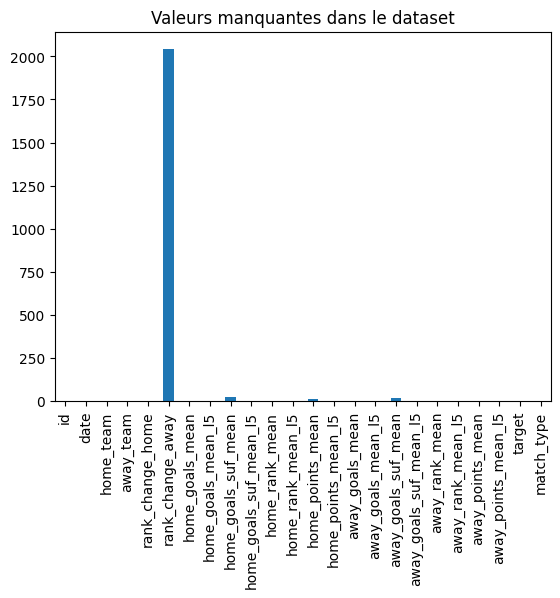

In [8]:
df.isnull().sum() .plot(kind='bar')
plt.title('Valeurs manquantes dans le dataset')
plt.show()

Répartition par classe pour la colonne 'target' : Le résultat du match. 1 pour une victoire, 0 pour une défaite ou un match nul.

In [9]:
df['target'].value_counts()

,count
target,
1,1976
0,1801


Visualisation de répartition par classe pour la colonne 'target'

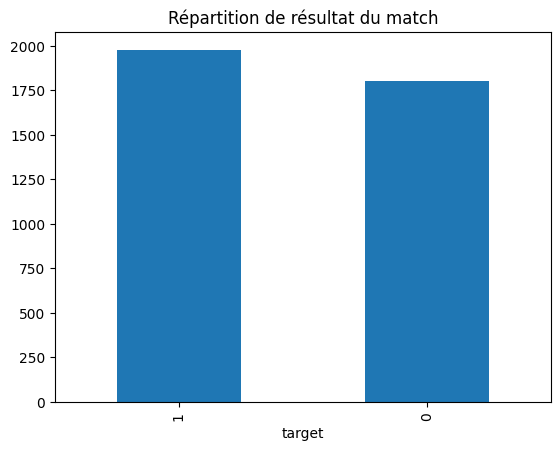

In [10]:
df['target'].value_counts().plot(kind='bar')
plt.title('Répartition de résultat du match')
plt.show()

Histogrammes

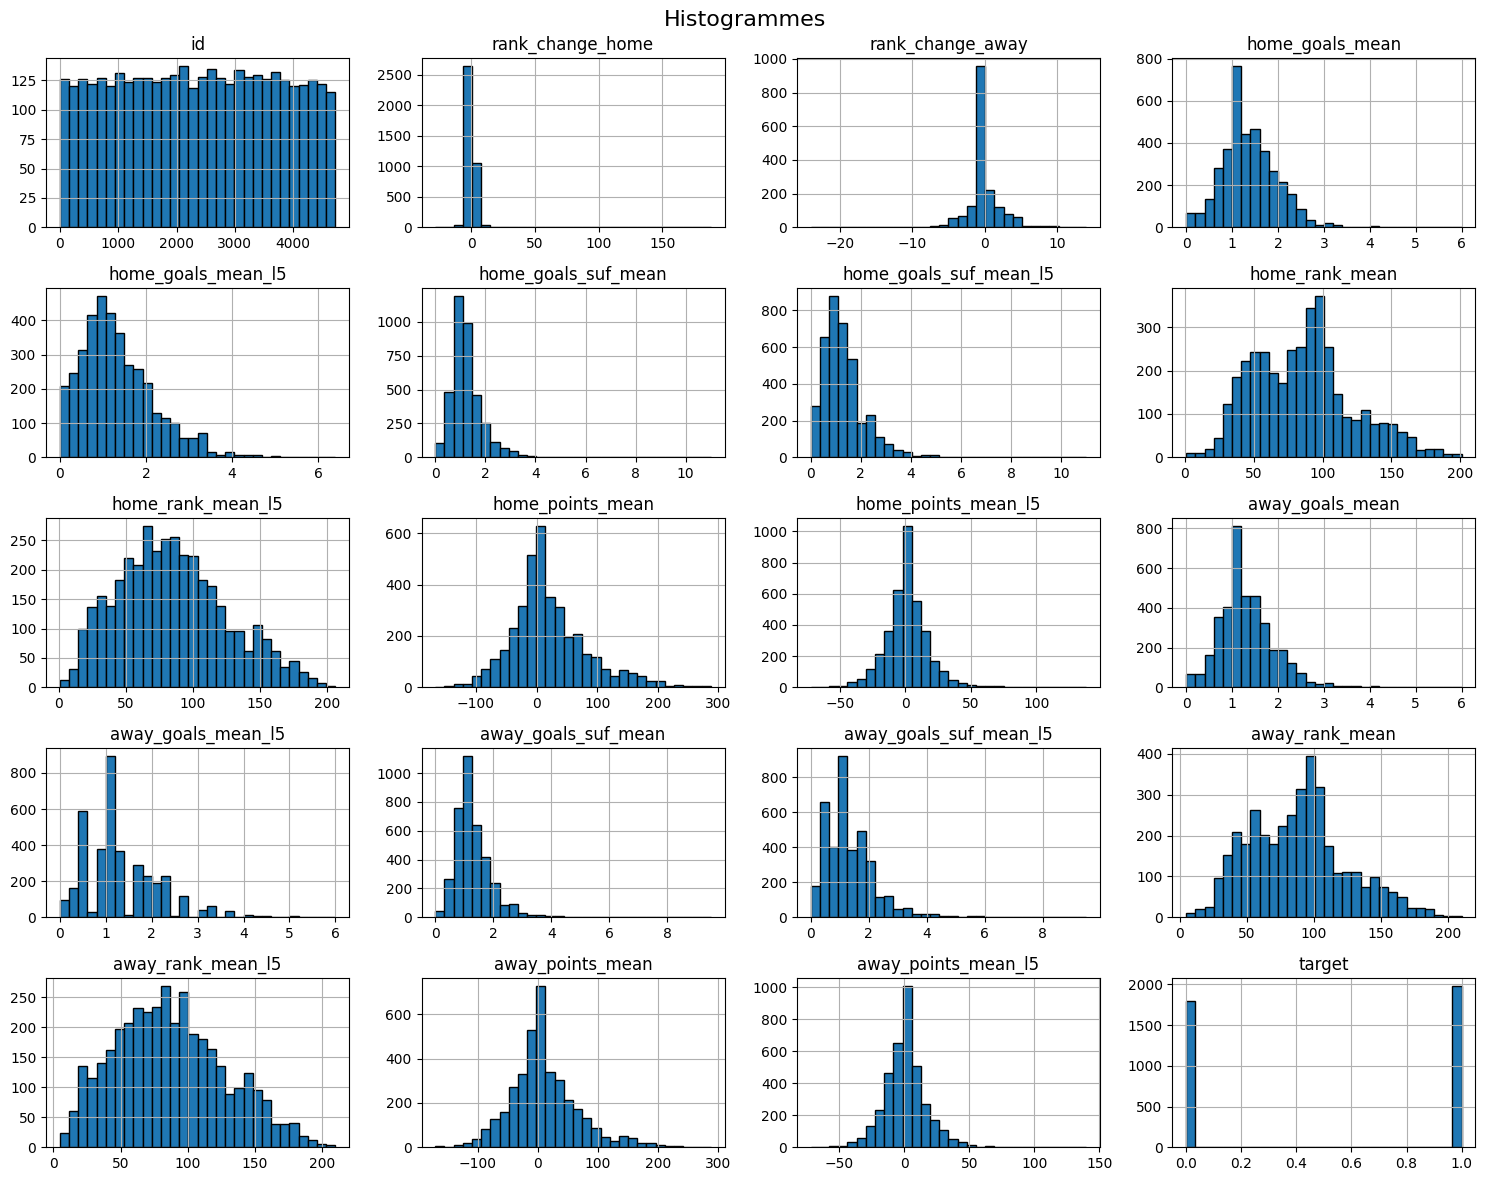

In [11]:
import matplotlib.pyplot as plt

df.hist(bins=30, figsize=(15, 12), edgecolor='black')
plt.suptitle("Histogrammes", fontsize=16)
plt.tight_layout()
plt.show()


Matrice de corrélation

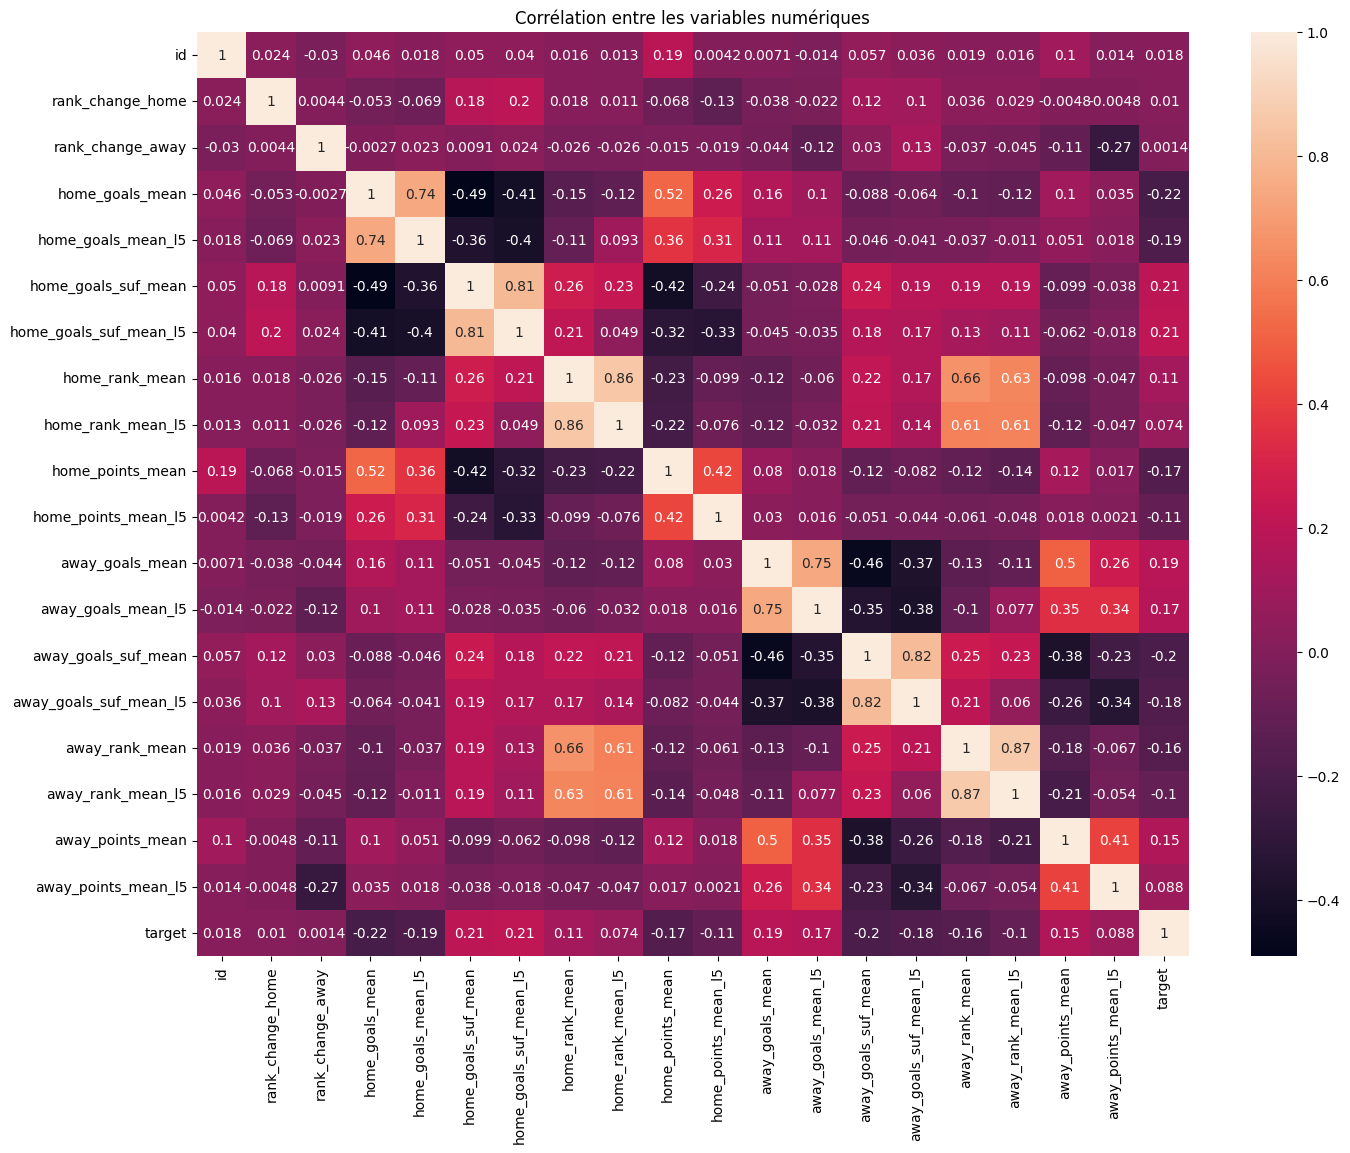

In [12]:

import seaborn as sns
plt.figure(figsize=(16, 12))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title('Corrélation entre les variables numériques')
plt.show()

Analyse de la Matrice de Corrélation:

Blanc / Beige : Corrélation positive forte (près de +1)

Noir : Corrélation négative forte (près de -1)

Violet foncé : Faible corrélation (proche de 0)

home_points_mean / away_points_mean : Corrélation positive

Une équipe qui marque beaucoup de points à domicile tend aussi à en marquer à l'extérieur

home_rank_mean vs. away_rank_mean : Faible corrélation

Si une équipe est bien classée à domicile, son classement à l'extérieur peut être similaire mais influencé par d'autres facteurs

Valeurs aberrantes Utilisation de la méthode IQR

In [13]:
# Sélectionner uniquement les colonnes numériques
colonnes_numériques = df.select_dtypes(include=['float64', 'int64'])

# Calcul de l'IQR
Q1 = colonnes_numériques.quantile(0.25)
Q3 = colonnes_numériques.quantile(0.75)
IQR = Q3 - Q1

valeurs_aberrantes = (colonnes_numériques < (Q1 - 1.5 * IQR)) | (colonnes_numériques > (Q3 + 1.5 * IQR))
# Remplacement des valeurs aberrantes par la médiane pour réduire leur impact
# Pour le  prétraitement
for col in colonnes_numériques.columns:
    médiane = df[col].median()
    df.loc[valeurs_aberrantes[col], col] = médiane
# Nombre de valeurs aberrantes par colonne
nb_outliers = valeurs_aberrantes.sum()

print("Nombre de valeurs aberrantes par colonne :")
print(nb_outliers[nb_outliers > 0])


Nombre de valeurs aberrantes par colonne :
rank_change_home          262
rank_change_away          102
home_goals_mean            64
home_goals_mean_l5        103
home_goals_suf_mean       193
home_goals_suf_mean_l5    177
home_rank_mean             45
home_rank_mean_l5          10
home_points_mean          200
home_points_mean_l5       206
away_goals_mean            77
away_goals_mean_l5        100
away_goals_suf_mean       184
away_goals_suf_mean_l5    122
away_rank_mean             41
away_rank_mean_l5           6
away_points_mean          209
away_points_mean_l5       197
dtype: int64


Données déséquilibrées

In [14]:
distribution_target = df['target'].value_counts(normalize=True)
print("Répartition de target:\n", distribution_target)

Répartition de target:
 target
1    0.523167
0    0.476833
Name: proportion, dtype: float64


les classes sont balancées car le nombre de victoires (1) et de défaites (0) est proche donc aucun besoin de techniques de rééquilibrage.



Données catégorielles

In [15]:
df.select_dtypes(include=["object", "category"]).columns

Index(['date', 'home_team', 'away_team', 'match_type'], dtype='object')

Imputation des valeurs manquantes

In [16]:
# Imputation des valeurs manquantes pour les colonnes numériques (médiane)
# Parce qu'il résiste aux valeurs aberrantes
df[df.select_dtypes(include=['float64', 'int64']).columns] = df[df.select_dtypes(include=['float64', 'int64']).columns].fillna(df[df.select_dtypes(include=['float64', 'int64']).columns].median())

In [17]:
# Vérifier que toutes les valeurs manquantes sont traitées
print(df.isnull().sum().sum())

0


2.Développement un modèle de Régression

Séparation des données :

Répartition entraînement/test

In [26]:
from sklearn.model_selection import train_test_split
X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


Mise à l'échelle des caractéristiques

Standardisation car il est utilisée pour les modèles sensibles aux écarts-types

In [27]:
from sklearn.preprocessing import StandardScaler

colonnes_numériques = X_train.select_dtypes(include=['float64', 'int64']).columns

scaler = StandardScaler()
X_train[colonnes_numériques] = scaler.fit_transform(X_train[colonnes_numériques])
X_test[colonnes_numériques] = scaler.transform(X_test[colonnes_numériques])

Nous allons tester 4 types de modèles :

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,  confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
models = {
    "Logistic Regression": LogisticRegression(
        random_state=22
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=None,
        min_samples_split=2,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=None,
        random_state=42
    ),

    "SVM": SVC(kernel='rbf', C=1.0)

}

Entraînement et comparaison des modèles

In [1]:
%%capture
%pip install mlflow dagshub

In [ ]:
results = {}

import mlflow
import mlflow.sklearn
import matplotlib.pyplot as plt

for name, model in models.items():

    with mlflow.start_run(run_name=name):

        # entraînement
        model.fit(X_train[colonnes_numériques], y_train)

        y_pred = model.predict(X_test[colonnes_numériques])

        # métriques
        accuracy = accuracy_score(y_test, y_pred)
        mlflow.log_metric("accuracy", accuracy)

        # paramètres
        mlflow.log_param("model", name)

        #  artefact 1 : sauvegarder le modèle
        mlflow.sklearn.log_model(model, name="model")

        #  artefact 2 : matrice de confusion (preuve visuelle)
        cm = confusion_matrix(y_test, y_pred)

        plt.figure()
        plt.imshow(cm)
        plt.title(f"Matrice de confusion - {name}")
        filename = f"cm_{name}.png"
        plt.savefig(filename)

        mlflow.log_artifact(filename)

        plt.close()

        results[name] = accuracy
        print(f"{name} Matrice de confusion  :")
        print(cm)
        print(f"{name} Accuracy: {accuracy:.4f}")
        print("---------------------------")

2026/03/18 20:29:31 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Logistic Regression Matrice de confusion  :
[[254 115]
 [102 285]]
Logistic Regression Accuracy: 0.7130
---------------------------


2026/03/18 20:29:35 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Random Forest Matrice de confusion  :
[[236 133]
 [110 277]]
Random Forest Accuracy: 0.6786
---------------------------


2026/03/18 20:29:40 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


XGBoost Matrice de confusion  :
[[244 125]
 [108 279]]
XGBoost Accuracy: 0.6918
---------------------------


2026/03/18 20:29:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


SVM Matrice de confusion  :
[[229 140]
 [109 278]]
SVM Accuracy: 0.6706
---------------------------


Comparaison finale

In [ ]:
results_df = pd.DataFrame(
    list(results.items()),
    columns=["Model", "Accuracy"]
)

print(results_df)

                 Model  Accuracy
0  Logistic Regression  0.712963
1        Random Forest  0.678571
2              XGBoost  0.691799
3                  SVM  0.670635


Courbe de comparaison des modèles

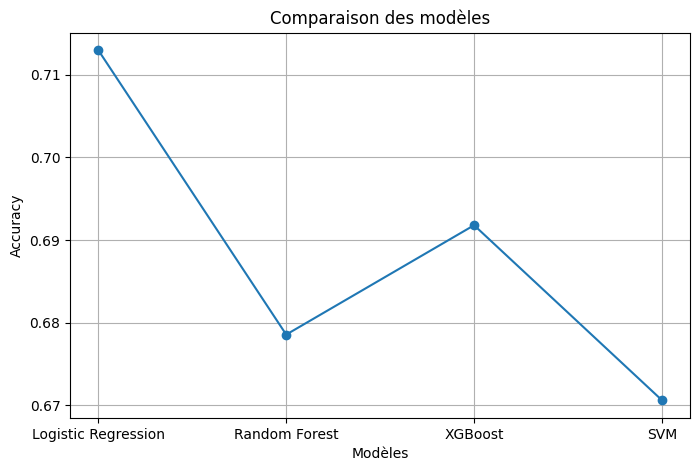

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(results_df["Model"], results_df["Accuracy"], marker='o')

plt.title("Comparaison des modèles")
plt.xlabel("Modèles")
plt.ylabel("Accuracy")

plt.grid(True)
plt.show()

Affichage de meilleur modèle

In [ ]:
best_model = max(results, key=results.get)

print("meilleur modèle:", best_model)
print("Accuracy:", results[best_model])

meilleur modèle: Logistic Regression
Accuracy: 0.7129629629629629


**La Logistic Regression** obtient la meilleure performance avec une accuracy de 71.30%, ce qui indique qu’elle est le modèle le plus adapté parmi ceux testés pour ce dataset.

Les modèles **Random Forest**, **Support Vector Machine et** **XGBoost** donnent des résultats légèrement inférieurs, montrant que leurs prédictions contiennent plus d’erreurs de classification.


Changement des hyperparamètres des modèles

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,  confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
import mlflow
import mlflow.sklearn

models_params = {
    "Logistic Regression": {
        "model": LogisticRegression(max_iter=1000),
        "params": {
            "C": [0.01, 0.1, 0.5, 1, 5, 10, 50],
            "solver": ["lbfgs", "liblinear"]
        }
    },
    "Random Forest": {
        "model": RandomForestClassifier(),
        "params": {
            "n_estimators": [100, 200, 300],
            "max_depth": [5, 10],
            "min_samples_split": [2, 5]
        }
    },
    "XGBoost": {
        "model": XGBClassifier(),
        "params": {
            "learning_rate": [0.01, 0.05, 0.1],
            "n_estimators": [100, 200, 300],
            "max_depth": [5, 7, 8]
        }
    },
    "SVM": {
        "model": SVC(),
        "params": {
            "C": [0.1, 1, 10],
            "kernel": ["linear", "rbf"]
        }
    }
}

results = {}

for name, mp in models_params.items():

    with mlflow.start_run(run_name=name):

        grid = GridSearchCV(mp["model"], mp["params"], cv=3, scoring='accuracy')
        grid.fit(X_train[colonnes_numériques], y_train)

        best_model = grid.best_estimator_

        y_pred = best_model.predict(X_test[colonnes_numériques])

        acc = accuracy_score(y_test, y_pred)

        # logs MLflow
        mlflow.log_metric("accuracy", acc)
        mlflow.log_params(grid.best_params_)
        mlflow.sklearn.log_model(best_model,name="model")

        print(f"{name} BEST Accuracy: {acc}")
        print(f"{name} BEST Params: {grid.best_params_}")
        print("----------------------")

        results[name] = acc

2026/03/23 17:49:51 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Logistic Regression BEST Accuracy: 0.7195767195767195
Logistic Regression BEST Params: {'C': 0.01, 'solver': 'liblinear'}
----------------------


2026/03/23 17:50:54 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Random Forest BEST Accuracy: 0.7103174603174603
Random Forest BEST Params: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
----------------------


2026/03/23 17:52:59 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


XGBoost BEST Accuracy: 0.6759259259259259
XGBoost BEST Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}
----------------------


2026/03/23 17:53:14 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


SVM BEST Accuracy: 0.7142857142857143
SVM BEST Params: {'C': 0.1, 'kernel': 'linear'}
----------------------


Une optimisation des hyperparamètres a été réalisée à l’aide de GridSearchCV afin d’identifier la meilleure configuration pour chaque modèle.Cette méthode permet de tester plusieurs combinaisons de paramètres afin de trouver celles qui donnent la meilleure accuracy sur les données d’entraînement.

Le modèle **Logistic Regression** obtient la meilleure performance avec une accuracy d’environ 71.95%. Les modèles **Random Forest, Support Vector Machine et XGBoost** présentent des performances légèrement inférieures, ce qui montre que la relation entre les variables du dataset est relativement bien capturée par un modèle linéaire.

**Documentation des modèles testés**


Régression Logistique

Hyperparamètres initiaux : alpha par défaut (C=1.0, solver=lbfgs)

Hyperparamètres optimisés : C=0.01, solver=liblinear

Performance (Accuracy) : 0.7195

Observation :Meilleur modèle parmi ceux testés, adapté aux relations linéaires du dataset.

---
Random Forest

Hyperparamètres initiaux : n_estimators=100, max_depth=None, min_samples_split=2

Hyperparamètres optimisés : n_estimators=100, max_depth=10, min_samples_split=5

Performance (Accuracy) : 0.7103

Observation : Performance légèrement inférieure à la régression logistique, mais capable de capturer des relations non linéaires.

---
XGBoost

Hyperparamètres initiaux : n_estimators=100, max_depth=None, learning_rate=0.1

Hyperparamètres optimisés : n_estimators=100, max_depth=5, learning_rate=0.1

Performance (Accuracy) : 0.6759

Observation : XGBoost n’a pas surpassé la régression logistique en raison de la structure simple et du faible nombre de features.

---
Support Vector Machine (SVM)

Hyperparamètres initiaux : kernel=rbf, C=1.0

Hyperparamètres optimisés : kernel=linear, C=0.1

Performance (Accuracy) : 0.7156

Observation : L’optimisation du paramètre C a amélioré légèrement la performance, mais reste en dessous de la régression logistique.

In [1]:
import os
import dagshub

os.environ["MLFLOW_TRACKING_USERNAME"] = "ihabbmb10"
os.environ["MLFLOW_TRACKING_PASSWORD"] = "eff466a1126cbd326f1db3c66008b98fc3e1064a"

dagshub.init(
    repo_owner="ihabbmb10",
    repo_name="scoresdematchsdefootball",
    mlflow=True
)

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=40da0a54-49f7-48e5-9480-fee75f86f2fe&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=41115db0dff60b47637a29b8aa040d187771c0535eaa3ee460b7d5c711f79bd8




Output()

Accessing as ihabbmb10

Initialized MLflow to track repo "ihabbmb10/scoresdematchsdefootball"

Repository ihabbmb10/scoresdematchsdefootball initialized!

In [3]:
import mlflow

mlflow.set_experiment("Prediction_scores_football")

2026/03/24 21:19:57 INFO mlflow.tracking.fluent: Experiment with name 'Prediction_scores_football' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/ac8feedfbc694544a0871293bfca7981', creation_time=1774401692131, experiment_id='1', last_update_time=1774401692131, lifecycle_stage='active', name='Prediction_scores_football', tags={}, workspace='default'>